In [3]:

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 120


In [4]:
filenames = [
    "M13_0001.fits",
    "M13_0002.fits",
    "M13_0003.fits",
    "M13_0004.fits",
    "M13_0005.fits",
]

data_list = []
header_list = []

for fname in filenames:
    with fits.open(fname) as hdul:
        header = hdul[0].header
        data = hdul[0].data
        
        data_list.append(data)
        header_list.append(header)
        print(f"Loaded {fname} with shape {data.shape}")

Loaded M13_0001.fits with shape (1040, 1392)
Loaded M13_0002.fits with shape (1040, 1392)
Loaded M13_0003.fits with shape (1040, 1392)
Loaded M13_0004.fits with shape (1040, 1392)
Loaded M13_0005.fits with shape (1040, 1392)


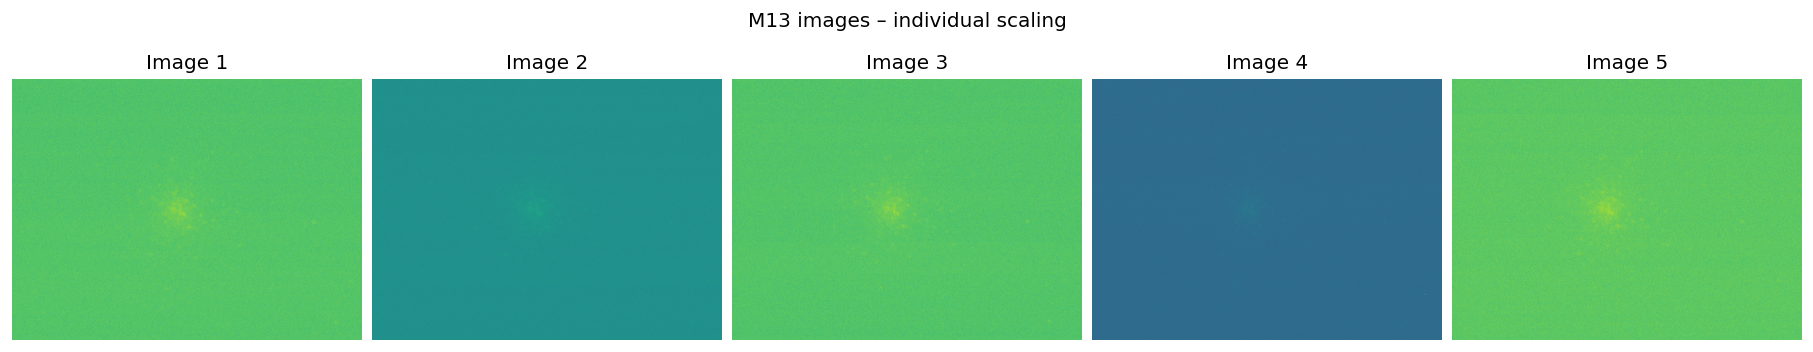

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3), constrained_layout=True)

for i, ax in enumerate(axes):
    im = ax.imshow(data_list[i], origin="lower")
    ax.set_title(f"Image {i+1}")
    ax.axis("off")

plt.suptitle("M13 images – individual scaling", y=1.05)
plt.show()

Global vmin: 0
Global vmax: 1447


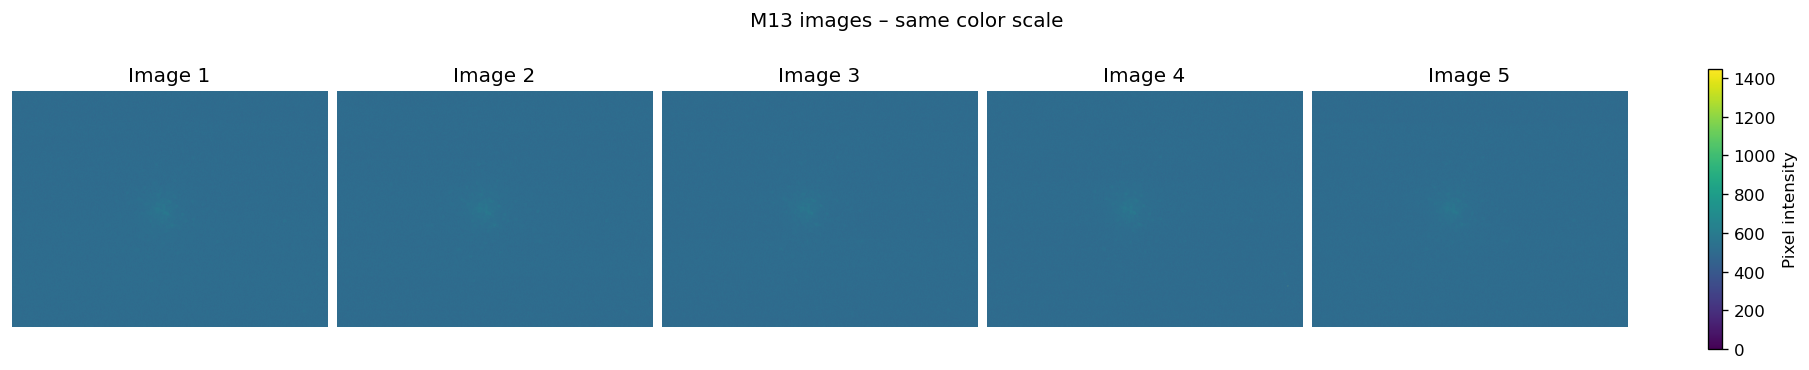

In [6]:
all_data = np.array(data_list)
vmin = np.min(all_data)
vmax = np.max(all_data)

print("Global vmin:", vmin)
print("Global vmax:", vmax)

fig, axes = plt.subplots(1, 5, figsize=(15, 3), constrained_layout=True)

# Use the first image for a shared colorbar
im = None
for i, ax in enumerate(axes):
    im = ax.imshow(data_list[i], origin="lower", vmin=vmin, vmax=vmax)
    ax.set_title(f"Image {i+1}")
    ax.axis("off")

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("Pixel intensity")

plt.suptitle("M13 images – same color scale", y=1.05)
plt.show()

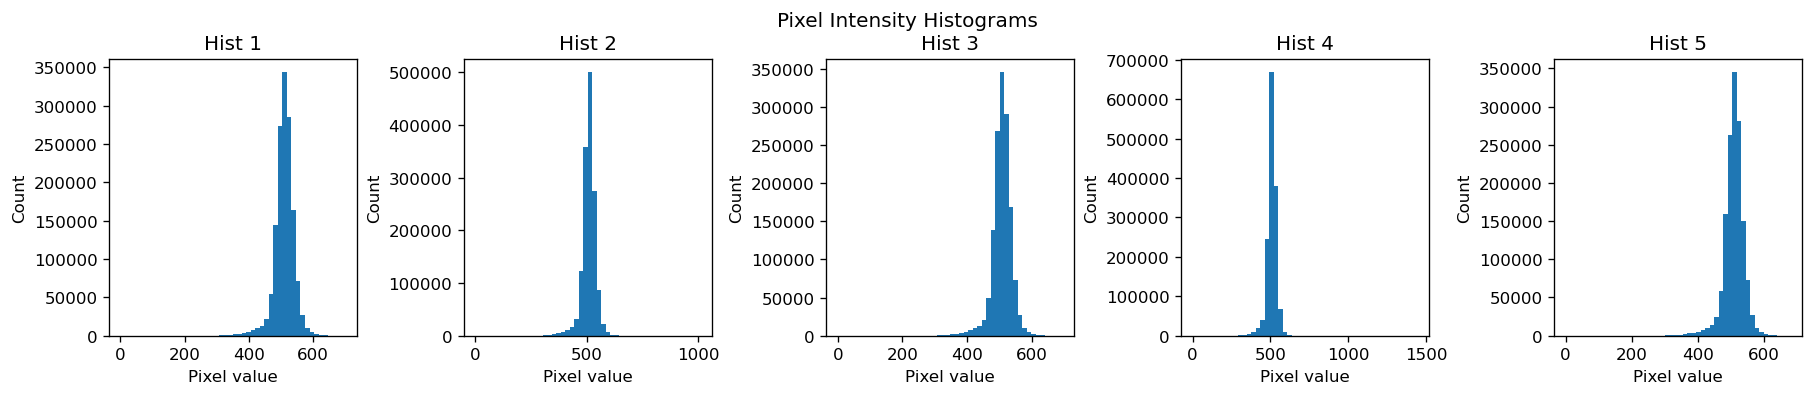

Image 1: mean = 510.47, median = 512.00
Image 2: mean = 509.75, median = 511.00
Image 3: mean = 508.05, median = 510.00
Image 4: mean = 507.91, median = 509.00
Image 5: mean = 508.79, median = 510.00


In [7]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3), constrained_layout=True)

for i, ax in enumerate(axes):
    data_flat = data_list[i].ravel()
    ax.hist(data_flat, bins=50)
    ax.set_title(f"Hist {i+1}")
    ax.set_xlabel("Pixel value")
    ax.set_ylabel("Count")

plt.suptitle("Pixel Intensity Histograms", y=1.05)
plt.show()

# Print mean/median for each
for i, data in enumerate(data_list):
    flat = data.ravel()
    mean_val = np.mean(flat)
    median_val = np.median(flat)
    print(f"Image {i+1}: mean = {mean_val:.2f}, median = {median_val:.2f}")


a
-x-axis: pixel intensity (brightness value of each pixel)  
- y-axis: number of pixels (how many pixels have that intensity)

b
-It splits the range of pixel values into 50 equally spaced intervals (“bins”) and counts how many pixels fall into each bin.

c 
-From the histograms, most pixel values cluster around the main peak near the background level which represents the sky/background level.

d
-The bulk of the data is relatively narrow around the background value, with a longer tail of higher-intensity pixels corresponding to stars and bright sources.



Median pixel intensity of combined image: 510.0


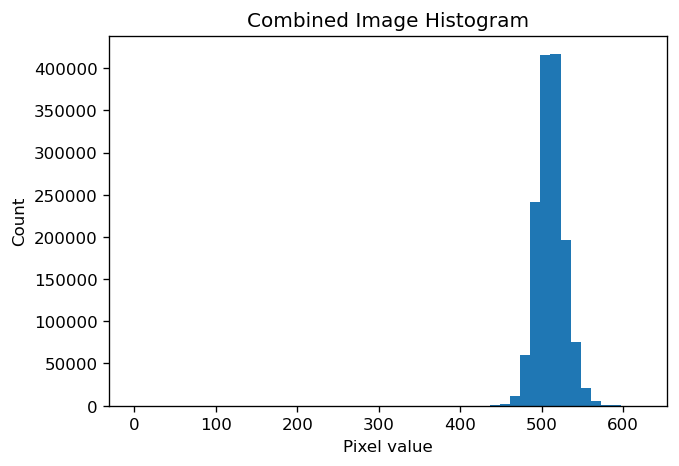

In [8]:
combined_image = np.median(np.array(data_list), axis=0)

combined_median = np.median(combined_image)
print("Median pixel intensity of combined image:", combined_median)

# Histogram of the combined image
plt.figure()
plt.hist(combined_image.ravel(), bins=50)
plt.xlabel("Pixel value")
plt.ylabel("Count")
plt.title("Combined Image Histogram")
plt.show()

Chosen vmin: 485.0
Chosen vmax: 539.0
Difference (vmax - vmin): 54.0


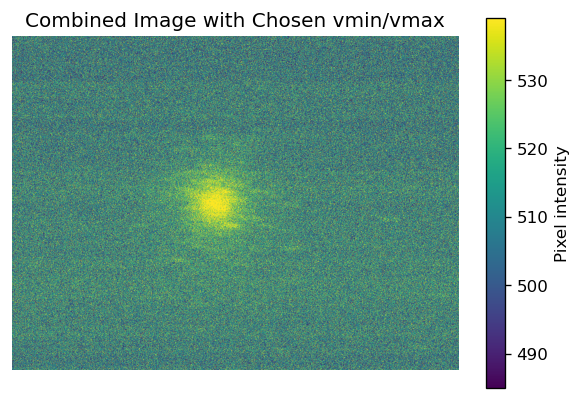

In [9]:
vmin = np.percentile(combined_image, 5)   # 5th percentile
vmax = np.percentile(combined_image, 95)  # 95th percentile

print("Chosen vmin:", vmin)
print("Chosen vmax:", vmax)
print("Difference (vmax - vmin):", vmax - vmin)

plt.figure()
plt.imshow(combined_image, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(label="Pixel intensity")
plt.title("Combined Image with Chosen vmin/vmax")
plt.axis("off")
plt.show()

In [10]:
output_filename = "combined.fits"
fits.writeto(output_filename, combined_image, overwrite=True)
print(f"Saved combined image to {output_filename}")

Saved combined image to combined.fits
